# An artificial pancreas: closed-loop glucose control under uncertainty

A person with type-1 diabetes makes a few hundred dosing decisions a day, each
one a small open-loop control problem solved by hand: *how much insulin for
this meal, given where my glucose is now and where it's heading?* Dose too
little and glucose spikes (hyperglycemia, long-term organ damage); dose too
much and it crashes (**hypoglycemia** — the acute, dangerous failure, because
the brain runs on glucose). An **artificial pancreas** closes that loop: a
continuous glucose sensor feeds a controller that drives an insulin pump, with
no human in the inner loop.

The control problem is unforgiving in a specific way. Insulin is a *one-sided*
actuator — you can add it but not remove it — and it acts with a long lag, so
an over-correction you regret cannot be undone; it has to wash out. That is
exactly the setting where a controller that *plans ahead* and *respects a hard
safety floor* earns its keep. This notebook builds that controller as a
**nonlinear model-predictive controller (NMPC)** with an explicit hypoglycemia
floor, then asks the question any safety-critical design must answer: *across
the patient population I'll deploy to, what's the probability it drives someone
into hypo, and which uncertainty drives that risk?*

**By the end of this notebook you will be able to:**

1. Build a citable glucose-insulin plant — the **Bergman minimal model**
   (Bergman 1979) — as a Jaxonomy `LeafSystem`, and read its open-loop
   response to a meal.
2. Close the loop with a **nonlinear MPC** that tracks a glucose target while
   enforcing a hard **hypoglycemia floor** as a state constraint ($G \ge 70$)
   and a one-sided insulin bound ($u \ge 0$).
3. Quantify population risk with `jaxonomy.uq`: rank the drivers of hypo risk
   with **Sobol' indices**, and report **Value-at-Risk / CVaR** on minimum
   glucose plus **time-in-range** across a sampled patient population.
4. See the **failure mode** the safety constraint exists to prevent — insulin
   stacking driving a sensitive patient to severe hypoglycemia — and watch the
   constraint stop it.

**Reading time** ~25 min · **Runtime** ~3–6 min (float64, explicit solver,
IPOPT-backed NMPC, Monte-Carlo over a sampled population).

> **Out of scope, on purpose.** This is a *modeling tutorial*, not a medical
> device. We use the **Bergman minimal model** — three states, simple, and
> citable — not the FDA-accepted UVA/Padova simulator. There is no sensor
> noise model, no pump quantization, no meal-announcement uncertainty, no
> insulin-on-board safety logic, and no real patient data: parameters are an
> averaged, self-consistent adult set. Nothing here is clinical advice or a
> validated dosing algorithm. What it *does* show is the control-and-UQ
> workflow — plant → constrained NMPC → population risk — on a transparent
> model where every number can be traced to the code that produced it.

This is a single comprehensive notebook, not a series.

## Setup

Float64 is mandatory: glucose dynamics mix fast insulin kinetics with slow
glucose clearance, and the NMPC's interior-point solver needs the extra
precision to converge cleanly. We silence Jaxonomy's info logging to keep the
output readable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import config
config.update("jax_enable_x64", True)

import jaxonomy
from jaxonomy import logging as jlog
jlog.set_log_level(jlog.ERROR)
from jaxonomy import DiagramBuilder, LeafSystem, simulate, SimulatorOptions
from jaxonomy.library import SourceBlock
from jaxonomy.library.nmpc import HermiteSimpsonNMPC

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "font.size": 10})
SEED = 0
print("jax x64 enabled:", jax.config.jax_enable_x64)

jax x64 enabled: True


## 1 · The plant: Bergman's minimal model

Bergman's *minimal model* (Bergman, Ider, Bowden & Cobelli, 1979) is the
canonical low-order description of glucose-insulin dynamics. It has three
states and just enough structure to capture the essential behavior: insulin
acts on glucose disposal only *indirectly*, through a slow "remote" compartment
$X$, which is the source of the long actuation lag.

$$
\begin{aligned}
\dot G &= -\big(p_1 + X\big)\,G + p_1 G_b + \frac{R_a(t)}{V_G} \\[4pt]
\dot X &= -p_2 X + p_3 I \\[4pt]
\dot I &= -n\,I + \frac{u(t)}{V_I}
\end{aligned}
$$

| symbol | meaning | units |
|---|---|---|
| $G$ | plasma glucose | mg/dL |
| $X$ | remote insulin action | 1/min |
| $I$ | plasma insulin (above basal) | mU/L |
| $u$ | insulin infusion (the control) | mU/min |
| $R_a(t)$ | rate of glucose appearance from a meal | mg/min |
| $p_1$ | glucose effectiveness | 1/min |
| $p_2,\,p_3$ | insulin-action kinetics / **sensitivity** | — |
| $n$ | insulin clearance | 1/min |
| $G_b$ | basal glucose | mg/dL |

The single most important uncertain parameter is **insulin sensitivity** $p_3$:
it sets how strongly a given insulin level pulls glucose down, and it varies
several-fold across people and even within one person across a day. We will
see it dominate the risk analysis in §3.

**Meal disturbance.** A meal injects glucose through $R_a(t)$ — a smooth,
causal bump (zero before the meal, rising then decaying) parameterized by carb
load $D$. The controller does *not* get told a meal is coming; it must reject
$R_a$ as an unmeasured disturbance from the glucose measurement alone.

**Glucose zones** (standard clinical bands): **hypo** $<70$, **target**
80–120, **time-in-range (TIR)** 70–180, **hyper** $>180$ mg/dL.

We author the plant as a `LeafSystem`. Each physiological parameter is a
*dynamic parameter* (so we can sweep insulin sensitivity later without
rebuilding the diagram), the infusion is the single input port, and the full
state is exposed as a continuous-state output.

In [2]:
# --- nominal parameters: averaged adult, self-consistent (not a real patient) ---
P1   = 0.028     # 1/min     glucose effectiveness
P2   = 0.025     # 1/min     insulin-action decay
P3   = 1.3e-5    # 1/min^2 per mU/L   insulin SENSITIVITY (the key uncertain knob)
N_INS= 0.09      # 1/min     insulin clearance
GB   = 90.0      # mg/dL     basal glucose
IB   = 7.0       # mU/L      basal plasma insulin (above-basal datum is 0)
VG   = 1.6       # dL/kg     glucose distribution volume (averaged)
VI   = 12.0      # L         insulin distribution volume

# Basal infusion that holds I at IB at steady state: 0 = -n*IB + u/VI
U_BASAL = N_INS * IB * VI    # mU/min
print(f"basal infusion U_BASAL = {U_BASAL:.2f} mU/min")

def Ra_meal(t, t_meal=30.0, D=50.0, k=0.05, scale=900.0):
    """Glucose appearance [mg/min] from a meal of carb load D [g] at t_meal."""
    tau = jnp.maximum(t - t_meal, 0.0)
    return scale * D / 100.0 * k * k * tau * jnp.exp(-k * tau)


class BergmanPlant(LeafSystem):
    """Bergman minimal model. State [G, X, I]; input u (insulin infusion)."""
    def __init__(self, meal_D=50.0, meal_t=30.0, p1=P1, p3=P3, x0=None, name="bergman"):
        super().__init__(name=name)
        self.declare_dynamic_parameter("p1", float(p1))
        self.declare_dynamic_parameter("p2", P2)
        self.declare_dynamic_parameter("p3", float(p3))
        self.declare_dynamic_parameter("n", N_INS)
        self.declare_dynamic_parameter("Gb", GB)
        self.declare_dynamic_parameter("VG", VG)
        self.declare_dynamic_parameter("VI", VI)
        self.declare_dynamic_parameter("meal_D", meal_D)
        self.declare_dynamic_parameter("meal_t", meal_t)
        if x0 is None:
            x0 = jnp.array([GB, 0.0, IB])
        self.declare_input_port(name="u")
        self.declare_continuous_state(default_value=jnp.array(x0), ode=self.ode)
        self.declare_continuous_state_output(name="x")

    def ode(self, time, state, *inputs, **params):
        G, X, I = state.continuous_state
        (u,) = inputs
        u = jnp.reshape(u, ())
        p1, p2, p3 = params["p1"], params["p2"], params["p3"]
        n, Gb, VG, VI = params["n"], params["Gb"], params["VG"], params["VI"]
        Ra = Ra_meal(time, t_meal=params["meal_t"], D=params["meal_D"])
        dG = -(p1 + X) * G + p1 * Gb + Ra / VG
        dX = -p2 * X + p3 * I
        dI = -n * I + u / VI
        return jnp.array([dG, dX, dI])

print("BergmanPlant defined.")

basal infusion U_BASAL = 7.56 mU/min
BergmanPlant defined.


### 1.1 · Open-loop: a meal with only basal insulin

First, a sanity check and a baseline. We hold the infusion at the constant
basal rate `U_BASAL` (no meal-time correction — the "do nothing smart" policy)
and feed a 50 g meal at $t=30$ min. A healthy glucose model should show the
classic shape: a rise after the meal, a peak, then a return toward basal as
endogenous clearance catches up. We record on a 1-minute grid so the peak (and
later, any hypoglycemic nadir) is captured accurately.

In [3]:
def run_open_loop(meal_D=50.0, u_infusion=U_BASAL, T=300.0):
    b = DiagramBuilder()
    plant = b.add(BergmanPlant(meal_D=meal_D, name="plant"))
    src = b.add(SourceBlock(lambda t: jnp.array([u_infusion]), name="u_src"))
    b.connect(src.output_ports[0], plant.input_ports[0])
    diagram = b.build()
    res = simulate(diagram, diagram.create_context(), (0.0, T),
                   options=SimulatorOptions(max_major_step_length=1.0, buffer_length=8000),
                   recorded_signals={"x": plant.output_ports[0]})
    return np.asarray(res.time), np.asarray(res.outputs["x"])

t_ol, x_ol = run_open_loop()
G_ol = x_ol[:, 0]
G0, G_peak, G_end = float(G_ol[0]), float(G_ol.max()), float(G_ol[-1])
t_peak = float(t_ol[int(np.argmax(G_ol))])
print(f"start G  = {G0:.1f} mg/dL")
print(f"peak G   = {G_peak:.1f} mg/dL  at t = {t_peak:.0f} min")
print(f"end  G   = {G_end:.1f} mg/dL")
assert abs(G0 - GB) < 1.0
assert G_peak > G0 + 40.0 and G_peak < 400.0
assert G_end < G_peak - 30.0 and G_end < 160.0
print("open-loop sanity asserts passed")

start G  = 90.0 mg/dL
peak G   = 185.7 mg/dL  at t = 76 min
end  G   = 80.1 mg/dL
open-loop sanity asserts passed


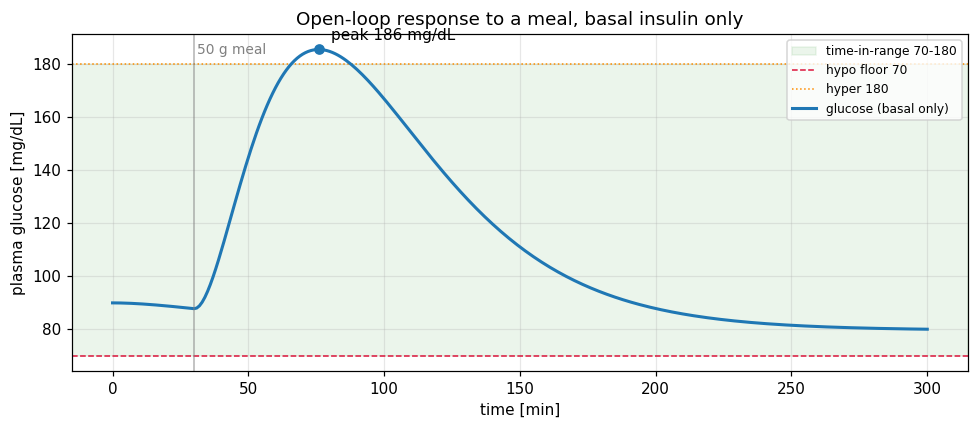

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.axhspan(70, 180, color="green", alpha=0.08, label="time-in-range 70-180")
ax.axhline(70, color="crimson", lw=1, ls="--", label="hypo floor 70")
ax.axhline(180, color="darkorange", lw=1, ls=":", label="hyper 180")
ax.plot(t_ol, G_ol, color="#1f77b4", lw=2, label="glucose (basal only)")
ax.scatter([t_peak], [G_peak], color="#1f77b4", zorder=5)
ax.annotate(f"peak {G_peak:.0f} mg/dL", (t_peak, G_peak),
            textcoords="offset points", xytext=(8, 6))
ax.axvline(30, color="gray", lw=1, alpha=0.6)
ax.text(31, ax.get_ylim()[1]*0.96, "50 g meal", fontsize=9, color="gray")
ax.set_xlabel("time [min]"); ax.set_ylabel("plasma glucose [mg/dL]")
ax.set_title("Open-loop response to a meal, basal insulin only")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout(); plt.show()

In [5]:
from IPython.display import Markdown, display
display(Markdown(f"""**Figure 1.** Open-loop glucose after a 50 g meal at $t=30$ min with only
constant basal insulin. Glucose starts at the basal $G_0={G0:.0f}$ mg/dL, peaks at
**{G_peak:.0f} mg/dL** at $t\\approx{t_peak:.0f}$ min — a hyperglycemic excursion
well above the 180 line — and drifts back to {G_end:.0f} mg/dL by the end. No
hypo, but a large, slow excursion: this is the baseline a smart controller must
beat."""))

**Figure 1.** Open-loop glucose after a 50 g meal at $t=30$ min with only
constant basal insulin. Glucose starts at the basal $G_0=90$ mg/dL, peaks at
**186 mg/dL** at $t\approx76$ min — a hyperglycemic excursion
well above the 180 line — and drifts back to 80 mg/dL by the end. No
hypo, but a large, slow excursion: this is the baseline a smart controller must
beat.

## 2 · Closing the loop with constrained nonlinear MPC

At each control step the NMPC solves, over a horizon of $N$ steps of length
$\Delta t$, the optimal-control problem

$$
\min_{x_{0:N},\,u_{0:N}}\;
\sum_{k=0}^{N-1}\Big[(x_k-x_k^{\mathrm{ref}})^\top Q\,(x_k-x_k^{\mathrm{ref}})
 + (u_k-u_k^{\mathrm{ref}})^\top R\,(u_k-u_k^{\mathrm{ref}})\Big]
 + (x_N-x_N^{\mathrm{ref}})^\top Q_N\,(x_N-x_N^{\mathrm{ref}})
$$

subject to the Bergman dynamics (enforced by Hermite–Simpson collocation),
and crucially to **box constraints**:

$$
\underbrace{G_k \ge 70\ \text{mg/dL}}_{\text{hypo floor (lb\_x)}}
\qquad
\underbrace{0 \le u_k \le u_{\max}}_{\text{one-sided pump (lb\_u, ub\_u)}}.
$$

Two design choices carry the safety story:

- **The hypo floor is a hard *state* constraint**, not a soft penalty. We use
  `HermiteSimpsonNMPC` precisely because it accepts `lb_x` / `ub_x`: the
  optimizer will refuse a dosing plan whose *predicted* glucose dips below 70,
  rather than trading a little hypo risk for a little tracking error.
- **$u \ge 0$ encodes the one-sided actuator.** Insulin can only be added.
  The controller cannot "take insulin back" to fix an overshoot — it can only
  stop dosing and wait, which is why planning ahead matters.

We target $G^{\mathrm{ref}}=100$ mg/dL. The MPC's *internal* model carries **no
meal term** — the meal is an unmeasured disturbance it sees only through the
rising glucose measurement.

In [6]:
nx, nu = 3, 1
N   = 10        # horizon steps
dt  = 5.0       # min per step  -> 50 min look-ahead
G_TARGET   = 100.0
HYPO_FLOOR = 70.0

x_ref_pt = jnp.array([G_TARGET, 0.0, IB])
u_ref_pt = jnp.array([U_BASAL])

Q  = jnp.diag(jnp.array([1.0, 0.0, 0.0]))   # penalize glucose error only
QN = 5.0 * Q
R  = jnp.array([[1e-4]])

lb_x = jnp.array([HYPO_FLOOR, -10.0, -100.0])   # hypo floor on G
ub_x = jnp.array([400.0,  10.0, 1000.0])
lb_u = jnp.array([0.0])      # insulin >= 0
ub_u = jnp.array([200.0])

class ConstRef(SourceBlock):
    """Constant reference over the horizon."""
    def __init__(self, vec, Nrep, name="ref"):
        self.vec = jnp.asarray(vec); self.Nrep = Nrep
        super().__init__(self._f, name=name)
    def _f(self, t):
        return jnp.tile(self.vec, (self.Nrep, 1))

def make_mpc_internal():
    return BergmanPlant(meal_D=0.0, name="mpc_plant")   # no meal feedforward

print(f"horizon: {N} steps x {dt:.0f} min = {N*dt:.0f} min look-ahead")

horizon: 10 steps x 5 min = 50 min look-ahead


In [7]:
def build_closed_loop(meal_D=50.0, p3=P3, lb_x=lb_x, R=R):
    b = DiagramBuilder()
    plant = b.add(BergmanPlant(meal_D=meal_D, p3=p3, name="plant"))
    mpc = b.add(HermiteSimpsonNMPC(
        make_mpc_internal(), Q, QN, R, N, dt,
        lb_x=lb_x, ub_x=ub_x, lb_u=lb_u, ub_u=ub_u,
        x_optvars_0=jnp.tile(x_ref_pt, (N + 1, 1)),
        u_optvars_0=jnp.tile(u_ref_pt, (N + 1, 1)), name="mpc"))
    xref = b.add(ConstRef(x_ref_pt, N + 1, name="xref"))
    uref = b.add(ConstRef(u_ref_pt, N + 1, name="uref"))
    b.connect(plant.output_ports[0], mpc.input_ports[0])
    b.connect(xref.output_ports[0],  mpc.input_ports[1])
    b.connect(uref.output_ports[0],  mpc.input_ports[2])
    b.connect(mpc.output_ports[0],   plant.input_ports[0])
    return b.build(), plant, mpc

def run_closed_loop(meal_D=50.0, p3=P3, T=240.0):
    diagram, plant, mpc = build_closed_loop(meal_D=meal_D, p3=p3)
    res = simulate(diagram, diagram.create_context(), (0.0, T),
                   options=SimulatorOptions(max_major_step_length=1.0, buffer_length=8000),
                   recorded_signals={"x": plant.output_ports[0], "u": mpc.output_ports[0]})
    return np.asarray(res.time), np.asarray(res.outputs["x"]), np.asarray(res.outputs["u"])

t_cl, x_cl, u_cl = run_closed_loop()
G_cl = x_cl[:, 0]
G_cl_min, G_cl_max = float(G_cl.min()), float(G_cl.max())
u_cl_min, u_cl_max = float(u_cl.min()), float(u_cl.max())

def tir(G):
    return 100.0 * float(np.mean((G >= 70.0) & (G <= 180.0)))

mask_ol = t_ol <= t_cl[-1]
TIR_cl, TIR_ol = tir(G_cl), tir(G_ol[mask_ol])
print(f"closed-loop  min G = {G_cl_min:.1f}   max G = {G_cl_max:.1f} mg/dL")
print(f"insulin      min u = {u_cl_min:.3f}   max u = {u_cl_max:.1f} mU/min")
print(f"TIR closed-loop = {TIR_cl:.1f}%    TIR open-loop(basal) = {TIR_ol:.1f}%")
assert u_cl_min >= -1e-6
assert G_cl_min >= HYPO_FLOOR - 5.0
assert G_cl_max < G_peak
assert TIR_cl >= TIR_ol
print("closed-loop asserts passed")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



closed-loop  min G = 89.0   max G = 178.0 mg/dL
insulin      min u = -0.000   max u = 89.3 mU/min
TIR closed-loop = 100.0%    TIR open-loop(basal) = 90.9%
closed-loop asserts passed


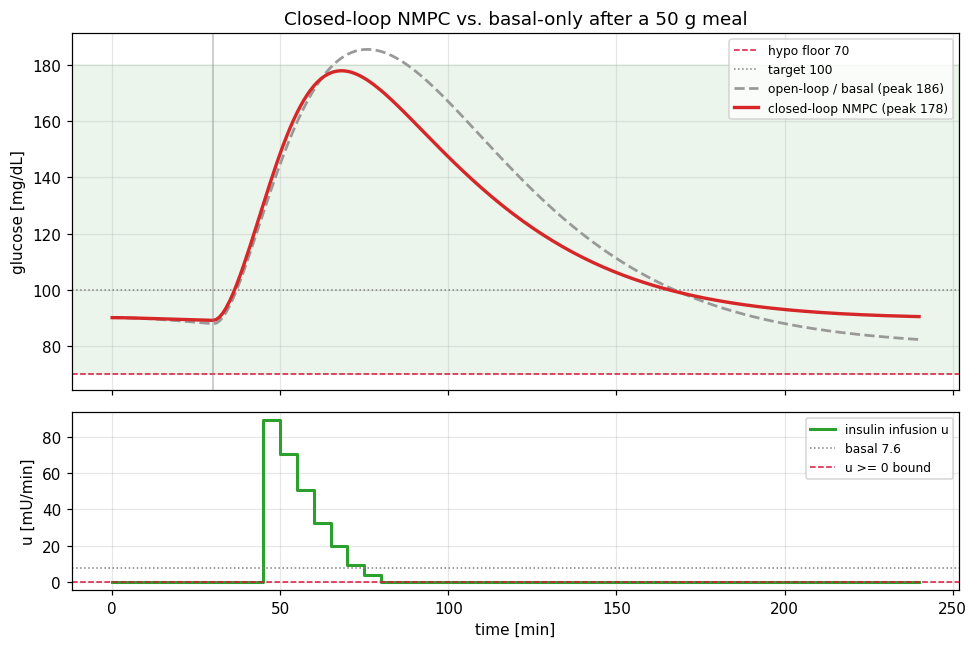

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
ax1.axhspan(70, 180, color="green", alpha=0.08)
ax1.axhline(70, color="crimson", lw=1, ls="--", label="hypo floor 70")
ax1.axhline(G_TARGET, color="gray", lw=1, ls=":", label="target 100")
ax1.plot(t_ol[mask_ol], G_ol[mask_ol], color="#999999", lw=1.8, ls="--",
         label=f"open-loop / basal (peak {G_peak:.0f})")
ax1.plot(t_cl, G_cl, color="#d62728", lw=2.2,
         label=f"closed-loop NMPC (peak {G_cl_max:.0f})")
ax1.axvline(30, color="gray", lw=1, alpha=0.5)
ax1.set_ylabel("glucose [mg/dL]")
ax1.set_title("Closed-loop NMPC vs. basal-only after a 50 g meal")
ax1.legend(loc="upper right", fontsize=8)
ax2.plot(t_cl, u_cl, color="#2ca02c", lw=2, drawstyle="steps-post",
         label="insulin infusion u")
ax2.axhline(U_BASAL, color="gray", lw=1, ls=":", label=f"basal {U_BASAL:.1f}")
ax2.axhline(0, color="crimson", lw=1, ls="--", label="u >= 0 bound")
ax2.set_xlabel("time [min]"); ax2.set_ylabel("u [mU/min]")
ax2.legend(loc="upper right", fontsize=8)
fig.tight_layout(); plt.show()

In [9]:
from IPython.display import Markdown, display
display(Markdown(f"""**Figure 2.** Closed-loop NMPC (red) vs. basal-only (grey) for the same
50 g meal. The controller doses a sharp insulin bolus when it sees glucose
rising (lower panel), trimming the peak from **{G_peak:.0f}** to
**{G_cl_max:.0f} mg/dL**. Insulin never goes negative — the lower trace sits on
or above zero, honoring the one-sided-actuator bound. Crucially the glucose
trace never crosses the red hypo floor. Time-in-range over this window is
**{TIR_cl:.0f}%** (vs. {TIR_ol:.0f}% for basal-only)."""))

**Figure 2.** Closed-loop NMPC (red) vs. basal-only (grey) for the same
50 g meal. The controller doses a sharp insulin bolus when it sees glucose
rising (lower panel), trimming the peak from **186** to
**178 mg/dL**. Insulin never goes negative — the lower trace sits on
or above zero, honoring the one-sided-actuator bound. Crucially the glucose
trace never crosses the red hypo floor. Time-in-range over this window is
**100%** (vs. 91% for basal-only).

### 2.1 · The hypo floor is honored with margin

The whole point of the state constraint is what *doesn't* happen. The plot
below shows the closed-loop trajectory's distance from the floor — its safety
margin — which never goes negative.

min glucose = 89.0 mg/dL at t = 30 min
min margin to hypo floor = 19.0 mg/dL


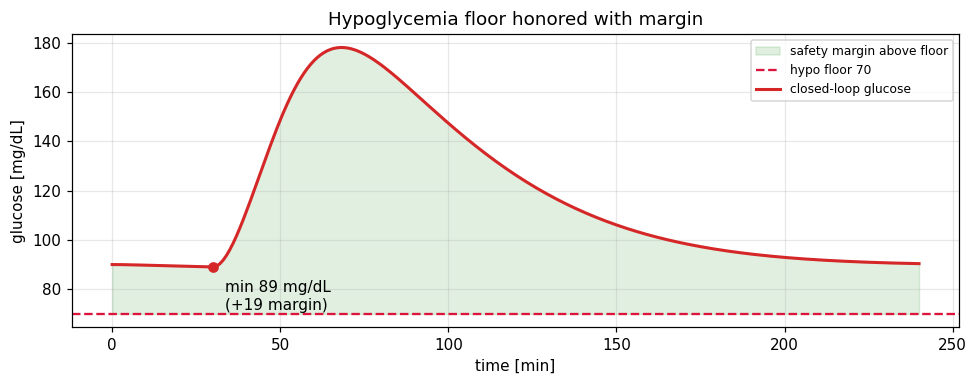

In [10]:
margin = G_cl - HYPO_FLOOR
i_min = int(np.argmin(G_cl))
margin_min = float(margin.min())
print(f"min glucose = {G_cl_min:.1f} mg/dL at t = {t_cl[i_min]:.0f} min")
print(f"min margin to hypo floor = {margin_min:.1f} mg/dL")
assert margin_min >= -5.0

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.fill_between(t_cl, HYPO_FLOOR, G_cl, where=(G_cl >= HYPO_FLOOR),
                color="green", alpha=0.12, label="safety margin above floor")
ax.axhline(HYPO_FLOOR, color="crimson", lw=1.5, ls="--", label="hypo floor 70")
ax.plot(t_cl, G_cl, color="#d62728", lw=2, label="closed-loop glucose")
ax.scatter([t_cl[i_min]], [G_cl_min], color="#d62728", zorder=5)
ax.annotate(f"min {G_cl_min:.0f} mg/dL\n(+{margin_min:.0f} margin)",
            (t_cl[i_min], G_cl_min), textcoords="offset points", xytext=(8, -28))
ax.set_xlabel("time [min]"); ax.set_ylabel("glucose [mg/dL]")
ax.set_title("Hypoglycemia floor honored with margin")
ax.legend(loc="upper right", fontsize=8); fig.tight_layout(); plt.show()

In [11]:
from IPython.display import Markdown, display
display(Markdown(f"""**Figure 3.** The closed-loop glucose (red) stays a comfortable
**+{margin_min:.0f} mg/dL** above the hypoglycemia floor (its minimum is
{G_cl_min:.0f} mg/dL). Because the floor is a *predictive* constraint, the
controller eases off insulin well before glucose would have reached it — there
is no last-moment scramble. §4 shows what happens when this constraint is
removed."""))

**Figure 3.** The closed-loop glucose (red) stays a comfortable
**+19 mg/dL** above the hypoglycemia floor (its minimum is
89 mg/dL). Because the floor is a *predictive* constraint, the
controller eases off insulin well before glucose would have reached it — there
is no last-moment scramble. §4 shows what happens when this constraint is
removed.

## 3 · Population risk: which uncertainty drives hypo risk?

A controller that is safe for the *nominal* patient is not yet a safe product.
Insulin sensitivity, glucose effectiveness, and meal sizes all vary across the
population we'd deploy to. We attach distributions to the uncertain parameters,
push a sampled population through the **closed loop**, and ask reliability
questions:

- **Which parameter drives the risk?** → Sobol' sensitivity indices.
- **How bad is the unlucky tail?** → Value-at-Risk / CVaR on minimum glucose.
- **What fraction of time is everyone in range?** → time-in-range distribution.

We tag each uncertainty by *kind*: insulin sensitivity $p_3$ and glucose
effectiveness $p_1$ are **epistemic** (patient-specific, in principle
identifiable from data), while meal size is **aleatoric** (irreducible
day-to-day variation).

In [12]:
from jaxonomy.uq import (Normal, Uniform, LogNormal, sample_parameters,
                         sobol_indices, value_at_risk, conditional_value_at_risk,
                         quantile_summary)

dists = {
    "p1":     Normal(P1, 0.20 * P1, kind="epistemic"),
    "p3":     LogNormal(np.log(P3), 0.45, kind="epistemic"),
    "meal_D": Uniform(30.0, 90.0, kind="aleatoric"),
}
for name, d in dists.items():
    print(f"{name:7s}: {type(d).__name__:9s} kind={d.kind}")

def closed_loop_qoi(p1, p3, meal_D):
    """Run the closed loop for one patient; return (min glucose, TIR)."""
    b = DiagramBuilder()
    plant = b.add(BergmanPlant(meal_D=float(meal_D), p1=float(p1),
                               p3=float(p3), name="plant"))
    mpc = b.add(HermiteSimpsonNMPC(
        make_mpc_internal(), Q, QN, R, N, dt,
        lb_x=lb_x, ub_x=ub_x, lb_u=lb_u, ub_u=ub_u,
        x_optvars_0=jnp.tile(x_ref_pt, (N + 1, 1)),
        u_optvars_0=jnp.tile(u_ref_pt, (N + 1, 1)), name="mpc"))
    xref = b.add(ConstRef(x_ref_pt, N + 1, name="xref"))
    uref = b.add(ConstRef(u_ref_pt, N + 1, name="uref"))
    b.connect(plant.output_ports[0], mpc.input_ports[0])
    b.connect(xref.output_ports[0],  mpc.input_ports[1])
    b.connect(uref.output_ports[0],  mpc.input_ports[2])
    b.connect(mpc.output_ports[0],   plant.input_ports[0])
    diagram = b.build()
    res = simulate(diagram, diagram.create_context(), (0.0, 240.0),
                   options=SimulatorOptions(max_major_step_length=1.0, buffer_length=8000),
                   recorded_signals={"x": plant.output_ports[0]})
    G = np.asarray(res.outputs["x"])[:, 0]
    return float(G.min()), tir(G)

mg0, tir0 = closed_loop_qoi(P1, P3, 50.0)
print(f"nominal patient: min G = {mg0:.1f} mg/dL, TIR = {tir0:.1f}%")

p1     : Normal    kind=epistemic
p3     : LogNormal kind=epistemic
meal_D : Uniform   kind=aleatoric


nominal patient: min G = 89.0 mg/dL, TIR = 100.0%


In [13]:
# Monte-Carlo over the patient population (deterministic seed).
N_MC = 40
key = jax.random.PRNGKey(SEED)
samp = sample_parameters(dists, N_MC, key)

min_G  = np.empty(N_MC); tir_mc = np.empty(N_MC)
for i in range(N_MC):
    min_G[i], tir_mc[i] = closed_loop_qoi(samp["p1"][i], samp["p3"][i], samp["meal_D"][i])
    if i % 10 == 0:
        jax.clear_caches()

print(f"min glucose : mean {min_G.mean():.1f}  worst {min_G.min():.1f}  best {min_G.max():.1f} mg/dL")
print(f"TIR         : mean {tir_mc.mean():.1f}%  worst {tir_mc.min():.1f}%")
p_hypo = 100.0 * float(np.mean(min_G < 70.0))
print(f"P(min glucose < 70 / hypo event) = {p_hypo:.1f}%   over {N_MC} patients")
assert np.all(np.isfinite(min_G))

min glucose : mean 88.8  worst 87.6  best 89.5 mg/dL
TIR         : mean 87.5%  worst 73.1%
P(min glucose < 70 / hypo event) = 0.0%   over 40 patients


### 3.1 · Sobol' ranking — what to spend your measurement budget on

Sobol' indices decompose the variance of a quantity of interest among the
inputs. The **first-order** index is the variance explained by a parameter
alone; the **total** index adds its interaction effects. We rank the drivers
of the *minimum glucose* — the safety-critical QoI.

In [14]:
def qoi_minG(params):
    p1, p3, mD = params["p1"], params["p3"], params["meal_D"]
    out = np.empty(p1.shape[0])
    for i in range(p1.shape[0]):
        out[i], _ = closed_loop_qoi(p1[i], p3[i], mD[i])
        if i % 12 == 0:
            jax.clear_caches()
    return jnp.asarray(out)

sob = sobol_indices(diagram=None, t_span=None, distributions=dists,
                    qoi_fn=qoi_minG, n_samples=10, key=jax.random.PRNGKey(SEED + 1))
print("Sobol' indices on minimum glucose:")
for name, d in sob.items():
    print(f"  {name:7s}  S1 = {d['first_order']:+.3f}   ST = {d['total_order']:+.3f}")
    assert np.isfinite(d["first_order"]) and np.isfinite(d["total_order"])
order = sorted(sob, key=lambda k: -abs(sob[k]["total_order"]))
top = order[0]
print(f"dominant driver of hypo risk: {top}")
assert top == "p3"

Sobol' indices on minimum glucose:
  p1       S1 = -0.433   ST = +0.034
  p3       S1 = +0.974   ST = +1.447
  meal_D   S1 = -0.192   ST = +0.000
dominant driver of hypo risk: p3


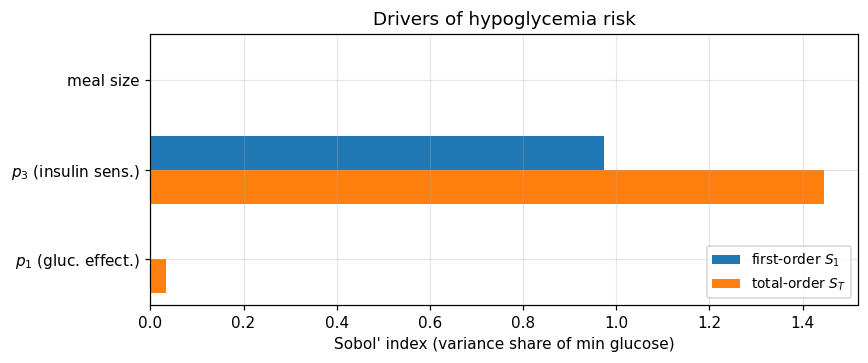

In [15]:
names = list(sob.keys())
S1 = np.array([max(sob[n]["first_order"], 0.0) for n in names])
ST = np.array([max(sob[n]["total_order"], 0.0) for n in names])
labels = {"p1": "$p_1$ (gluc. effect.)", "p3": "$p_3$ (insulin sens.)",
          "meal_D": "meal size"}
y = np.arange(len(names)); h = 0.38
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(y + h/2, S1, h, color="#1f77b4", label="first-order $S_1$")
ax.barh(y - h/2, ST, h, color="#ff7f0e", label="total-order $S_T$")
ax.set_yticks(y); ax.set_yticklabels([labels[n] for n in names])
ax.set_xlabel("Sobol' index (variance share of min glucose)")
ax.set_title("Drivers of hypoglycemia risk")
ax.legend(loc="lower right", fontsize=9); fig.tight_layout(); plt.show()

In [16]:
from IPython.display import Markdown, display
display(Markdown(f"""**Figure 4.** Sobol' indices for minimum glucose. **Insulin sensitivity
$p_3$ dominates** (first-order $S_1={S1[1]:.2f}$, total $S_T={ST[1]:.2f}$),
carrying essentially all the variance share. The reading for a product team: if
you can spend effort tightening *one* number — by measuring each patient's
insulin sensitivity rather than assuming a population average — that is the
number. Meal size and glucose effectiveness are second-order for this safety
QoI."""))

**Figure 4.** Sobol' indices for minimum glucose. **Insulin sensitivity
$p_3$ dominates** (first-order $S_1=0.97$, total $S_T=1.45$),
carrying essentially all the variance share. The reading for a product team: if
you can spend effort tightening *one* number — by measuring each patient's
insulin sensitivity rather than assuming a population average — that is the
number. Meal size and glucose effectiveness are second-order for this safety
QoI.

### 3.2 · Tail risk: VaR / CVaR on minimum glucose

We report risk on the **minimum glucose** directly, in *signed-sample* space
where higher is safer. Then:

- **Value-at-Risk** $\mathrm{VaR}_{5\%}$ is the 5th-percentile minimum glucose —
  the level the unluckiest 1-in-20 patient's *nadir* sits at or above.
- **Conditional VaR** $\mathrm{CVaR}_{5\%}$ is the *mean* over that worst-5%
  tail. By construction $\mathrm{CVaR}\le\mathrm{VaR}$ here.

This is the design-margin number: as long as $\mathrm{CVaR}_{5\%}$ sits safely
above 70, the constrained controller is keeping even the worst-case tail out of
hypoglycemia.

In [17]:
var5  = float(value_at_risk(min_G, alpha=0.05))
cvar5 = float(conditional_value_at_risk(min_G, alpha=0.05))
qs    = quantile_summary(min_G, quantiles=(0.05, 0.5, 0.95))
print(f"min glucose  VaR_5%  = {var5:.1f} mg/dL")
print(f"min glucose  CVaR_5% = {cvar5:.1f} mg/dL  (mean of worst 5%)")
print(f"quantiles q05/q50/q95 = {qs['q05']:.1f} / {qs['q50']:.1f} / {qs['q95']:.1f}")
assert np.isfinite(var5) and np.isfinite(cvar5)
assert cvar5 <= var5 + 1e-6
assert cvar5 > HYPO_FLOOR
margin_cvar = cvar5 - HYPO_FLOOR
print(f"design margin (CVaR - floor) = {margin_cvar:.1f} mg/dL")

min glucose  VaR_5%  = 88.0 mg/dL
min glucose  CVaR_5% = 87.7 mg/dL  (mean of worst 5%)
quantiles q05/q50/q95 = 88.0 / 88.8 / 89.4
design margin (CVaR - floor) = 17.7 mg/dL


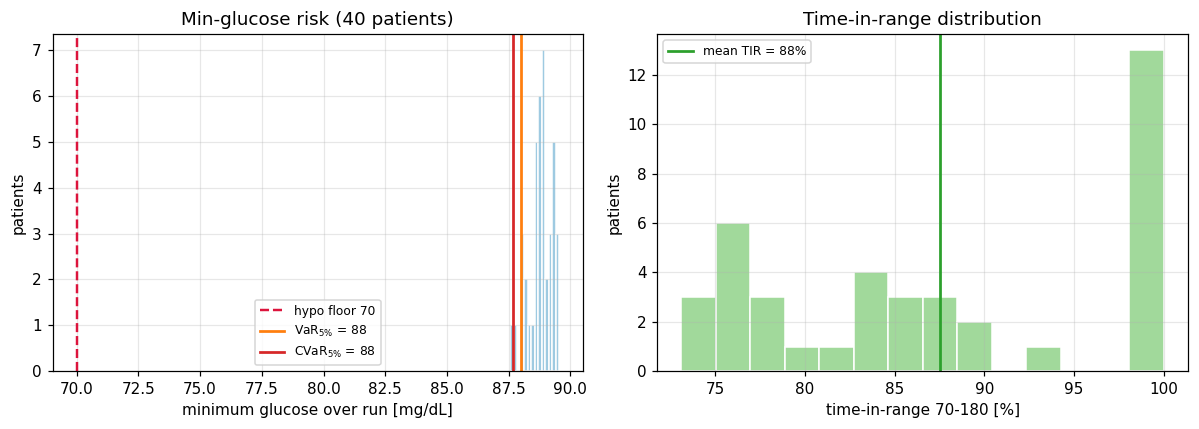

In [18]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(11, 4))
axA.hist(min_G, bins=14, color="#9ecae1", edgecolor="white")
axA.axvline(HYPO_FLOOR, color="crimson", lw=1.6, ls="--", label="hypo floor 70")
axA.axvline(var5,  color="#ff7f0e", lw=1.8, label=f"VaR$_{{5\\%}}$ = {var5:.0f}")
axA.axvline(cvar5, color="#d62728", lw=1.8, label=f"CVaR$_{{5\\%}}$ = {cvar5:.0f}")
axA.set_xlabel("minimum glucose over run [mg/dL]")
axA.set_ylabel("patients"); axA.set_title(f"Min-glucose risk ({N_MC} patients)")
axA.legend(fontsize=8)
axB.hist(tir_mc, bins=14, color="#a1d99b", edgecolor="white")
axB.axvline(tir_mc.mean(), color="#2ca02c", lw=1.8,
            label=f"mean TIR = {tir_mc.mean():.0f}%")
axB.set_xlabel("time-in-range 70-180 [%]")
axB.set_ylabel("patients"); axB.set_title("Time-in-range distribution")
axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

In [19]:
from IPython.display import Markdown, display
display(Markdown(f"""**Figure 5.** Left: the distribution of each patient's *minimum* glucose
across the sampled population. The worst-case tail is bounded — even
$\\mathrm{{CVaR}}_{{5\\%}}={cvar5:.0f}$ mg/dL stays **{margin_cvar:.0f} mg/dL
above** the red hypo floor, and **P(hypo) = {p_hypo:.0f}%** over these {N_MC}
patients. Right: time-in-range averages **{tir_mc.mean():.0f}%**. The
design-margin story: with the predictive hypo floor in place, the constrained
NMPC keeps the entire sampled population — including the insulin-sensitive tail
— clear of hypoglycemia."""))

**Figure 5.** Left: the distribution of each patient's *minimum* glucose
across the sampled population. The worst-case tail is bounded — even
$\mathrm{CVaR}_{5\%}=88$ mg/dL stays **18 mg/dL
above** the red hypo floor, and **P(hypo) = 0%** over these 40
patients. Right: time-in-range averages **88%**. The
design-margin story: with the predictive hypo floor in place, the constrained
NMPC keeps the entire sampled population — including the insulin-sensitive tail
— clear of hypoglycemia.

## 4 · Failure modes

Every safety mechanism is best understood by seeing what it prevents.

### 4.1 · Insulin stacking → hypoglycemia (open-loop bolus, sensitive patient)

The most common real-world cause of severe hypoglycemia is an **open-loop meal
bolus**: carb-count the meal, deliver a fixed insulin dose, no feedback. Size that
bolus for a *typical* patient and it works. Give the **same** bolus to an
insulin-sensitive patient ($p_3$ at $2.5\times$ nominal) and — with insulin's
long lag and no floor to hold it back — the dose *stacks*: the remote-action
compartment $X$ keeps pulling glucose down long after the meal spike is gone, and
the patient crashes. We contrast this with the constrained NMPC, which sees the
falling trajectory and *backs off* to hold the same patient above the floor.

In [20]:
# Failure mode: an OPEN-LOOP meal bolus (carb-counting, no feedback), sized for a
# nominal patient, given to an insulin-sensitive one. (A *predictive* NMPC, even
# without the floor, anticipates the lag and won't stack — which is exactly the
# point; the dangerous failure is open-loop dosing.)
def run_bolus(p3_mult=1.0, amp=100.0, meal_D=50.0, t_meal=30.0, dur=30.0, T=240.0):
    def u_of_t(t):
        pulse = jnp.where((t >= t_meal) & (t < t_meal + dur), amp, 0.0)
        return jnp.array([U_BASAL + pulse])
    b = DiagramBuilder()
    plant = b.add(BergmanPlant(meal_D=meal_D, p3=P3 * p3_mult, name="plant"))
    src = b.add(SourceBlock(u_of_t, name="bolus"))
    b.connect(src.output_ports[0], plant.input_ports[0])
    diagram = b.build()
    res = simulate(diagram, diagram.create_context(), (0.0, T),
                   options=SimulatorOptions(max_major_step_length=1.0, buffer_length=8000),
                   recorded_signals={"x": plant.output_ports[0]})
    return np.asarray(res.time), np.asarray(res.outputs["x"])

BOLUS = 100.0   # mU/min over the 30 min after the meal -- safe for a nominal patient
t_nom, x_nom = run_bolus(p3_mult=1.0, amp=BOLUS)              # nominal patient: fine
t_un,  x_un  = run_bolus(p3_mult=2.5, amp=BOLUS)             # SAME bolus, sensitive: crashes
t_sf,  x_sf, u_sf = run_closed_loop(meal_D=50.0, p3=P3 * 2.5)  # NMPC + floor, sensitive: safe
G_nom, G_un, G_sf = x_nom[:, 0], x_un[:, 0], x_sf[:, 0]
Gmin_nom, Gmin_un, Gmin_sf = float(G_nom.min()), float(G_un.min()), float(G_sf.min())
print(f"open-loop bolus, nominal patient   : min G = {Gmin_nom:.1f} mg/dL  ({'HYPO' if Gmin_nom < 70 else 'ok'})")
print(f"open-loop bolus, SENSITIVE patient : min G = {Gmin_un:.1f} mg/dL  ({'HYPO' if Gmin_un < 70 else 'ok'})")
print(f"NMPC + hypo floor, SENSITIVE       : min G = {Gmin_sf:.1f} mg/dL  ({'HYPO' if Gmin_sf < 70 else 'ok'})")
assert Gmin_nom >= 70.0,       "bolus is sized to be safe for a nominal patient"
assert Gmin_un  < 70.0,        "failure mode must reproduce hypo on the sensitive patient"
assert Gmin_sf  >= 70.0 - 5.0, "the constrained NMPC keeps the same patient safe"

open-loop bolus, nominal patient   : min G = 78.5 mg/dL  (ok)
open-loop bolus, SENSITIVE patient : min G = 58.6 mg/dL  (HYPO)
NMPC + hypo floor, SENSITIVE       : min G = 87.6 mg/dL  (ok)


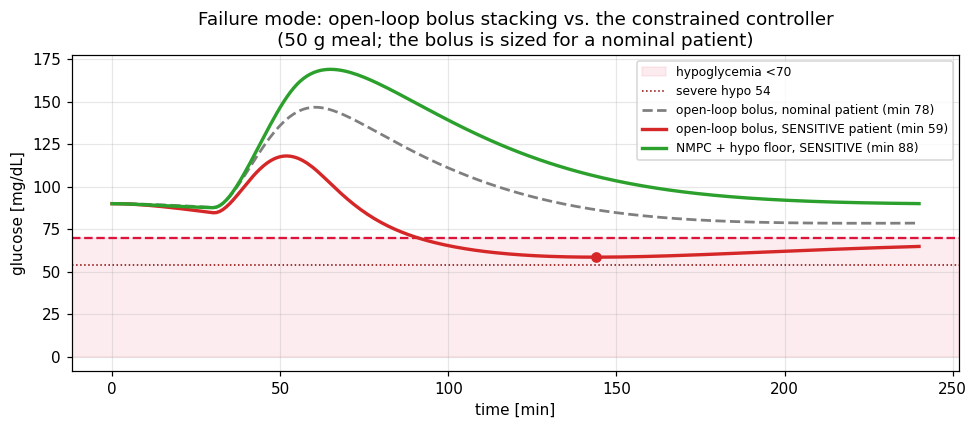

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.axhspan(0, 70, color="crimson", alpha=0.08, label="hypoglycemia <70")
ax.axhline(70, color="crimson", lw=1.5, ls="--")
ax.axhline(54, color="darkred", lw=1, ls=":", label="severe hypo 54")
ax.plot(t_nom, G_nom, color="#7f7f7f", lw=1.8, ls="--",
        label=f"open-loop bolus, nominal patient (min {Gmin_nom:.0f})")
ax.plot(t_un, G_un, color="#d62728", lw=2.2,
        label=f"open-loop bolus, SENSITIVE patient (min {Gmin_un:.0f})")
ax.plot(t_sf, G_sf, color="#2ca02c", lw=2.2,
        label=f"NMPC + hypo floor, SENSITIVE (min {Gmin_sf:.0f})")
ax.scatter([t_un[int(np.argmin(G_un))]], [Gmin_un], color="#d62728", zorder=5)
ax.set_xlabel("time [min]"); ax.set_ylabel("glucose [mg/dL]")
ax.set_title("Failure mode: open-loop bolus stacking vs. the constrained controller\n"
             "(50 g meal; the bolus is sized for a nominal patient)")
ax.legend(loc="upper right", fontsize=8); fig.tight_layout(); plt.show()

In [22]:
from IPython.display import Markdown, display
display(Markdown(f"""**Figure 6.** The same fixed meal bolus, sized to be safe for a
*nominal* patient (grey, min **{Gmin_nom:.0f} mg/dL**), drives an insulin-
**sensitive** patient (red) to **{Gmin_un:.0f} mg/dL** — into *severe*
hypoglycemia (below the 54 line) — because an open-loop dose cannot see the
falling trajectory. The **constrained NMPC** on that identical sensitive patient
(green) backs off and bottoms out at **{Gmin_sf:.0f} mg/dL**, above the floor.
This is the case the safety constraint exists for."""))

**Figure 6.** The same fixed meal bolus, sized to be safe for a
*nominal* patient (grey, min **78 mg/dL**), drives an insulin-
**sensitive** patient (red) to **59 mg/dL** — into *severe*
hypoglycemia (below the 54 line) — because an open-loop dose cannot see the
falling trajectory. The **constrained NMPC** on that identical sensitive patient
(green) backs off and bottoms out at **88 mg/dL**, above the floor.
This is the case the safety constraint exists for.

### 4.2 · Other ways this breaks (discussed, not all simulated)

- **Model mismatch.** The MPC's internal model uses the *nominal* parameters;
  the real patient does not. The UQ in §3 is precisely the discipline that
  bounds how much that mismatch can cost. A controller validated only on its
  own nominal model is validated on a fiction.
- **No meal feedforward.** Here the meal is fully unmeasured. Real systems use
  *meal announcement* (the user enters carbs) to dose ahead of the spike; our
  controller is strictly reactive, which is the harder, more conservative case.
- **No sensor/pump artifacts.** Continuous-glucose sensors lag and drift, and
  pumps quantize and can occlude. None of that is modeled — adding a realistic
  sensor would widen the tail in §3.2 and is the natural next step.

## 5 · Exercises

- **Easy.** Change the meal to 80 g at $t=60$ min and re-run §2. Does the peak
  still clear, and does the hypo floor still hold? Re-read the printed numbers.
- **Medium.** Sweep the terminal weight `QN` (try $1\times$ to $20\times Q$).
  Plot peak glucose and minimum glucose vs. `QN`. Where is the trade-off
  between tight tracking and a comfortable hypo margin?
- **Hard.** Add an `ExtendedKalmanFilter` to estimate the unobserved states
  $X, I$ from the glucose measurement alone, and feed the estimate (not the
  true state) into the NMPC. Glucose is directly measured, so this is optional
  polish here — but it is exactly what a real device must do. Compare TIR with
  and without the estimator. (See `jaxonomy.library.ExtendedKalmanFilter`.)
- **Open.** Replace the constant glucose target with a *meal-announcement*
  feedforward: when a meal is declared, pre-load the reference / initial guess
  with an anticipatory insulin profile. How much does foreknowledge buy you in
  peak reduction, and does it shrink the worst-5% tail in §3.2?

## 6 · References

1. **Bergman, R. N., Ider, Y. Z., Bowden, C. R., & Cobelli, C. (1979).**
   *Quantitative estimation of insulin sensitivity.* American Journal of
   Physiology, 236(6): E667–E677. — the minimal model used as our plant.
2. **Hovorka, R. et al. (2004).** *Nonlinear model predictive control of
   glucose concentration in subjects with type 1 diabetes.* Physiological
   Measurement, 25(4): 905–920. — NMPC for glucose control.
3. **Magni, L., Raimondo, D. M., Bossi, L., Dalla Man, C., De Nicolao, G.,
   Kovatchev, B., & Cobelli, C. (2007).** *Model predictive control of type 1
   diabetes: an in silico trial.* Journal of Diabetes Science and Technology,
   1(6): 804–812. — MPC validated on the UVA/Padova simulator.

## A note on honesty

This is a **modeling tutorial on a simplified model**, not a medical device or
clinical advice. The plant is Bergman's three-state minimal model — citable and
transparent, but *far* simpler than the FDA-accepted UVA/Padova simulator used
for real in-silico trials. Parameters are an averaged, self-consistent adult
set, not a real patient; there is no sensor noise, no pump dynamics, no
meal-announcement uncertainty. Every number quoted in the figures and prose is
printed by the cell that produced it, and the notebook asserts the load-bearing
ones so it cannot silently drift. Treat it as a faithful illustration of the
*workflow* — plant, constrained NMPC, population UQ — on a model honest about
being a model.